# Radio Occultation Validation: PlanetiQ and GPS

This notebook repeats the [COSMIC-2 radio occultation validation](ValidateROCOSMIC2.ipynb) for receivers in polar orbits: [PlanetiQ](https://www.planetiq.com/)'s GNOMES-4 and GNOMES-5 satellites, receiving GPS signals on the same day, 14 May 2026. COSMIC-2's 24 deg orbit inclination confines its tangent points to roughly ±45 deg latitude; the GNOMES satellites fly sun-synchronous orbits (97.5 and 97.7 deg inclination, about 570 km altitude) and sample every latitude, including the polar regions. The tests and methods are those of the COSMIC-2 notebook.

**Part 1** compares tangent point definitions using recorded PlanetiQ and GPS positions rather than propagated orbits, so that orbit errors play no part. TAT-C uses the *ellipsoidal* tangent point, the point on the straight transmitter–receiver line with minimum WGS 84 geodetic altitude; the simpler *geocentric* tangent point is the point on the line closest to Earth's center.

1. **Size of the difference.** For real PlanetiQ/GPS geometries, how far apart are the two tangent points, and how much do their heights and timing differ?
2. **Operational convention.** Which definition matches the tangent point geolocation in operationally processed PlanetiQ data, including at high latitudes?
3. **Practical significance.** How does the difference compare with the difference between TAT-C's representative point (the straight-line tangent point at `sample_elevation`, -80 km by default) and the reported location of each occultation?

**Part 2** runs `collect_ro_observations` end to end with orbits for the same day and compares its predictions with every GPS occultation PlanetiQ recorded:

4. **Orbits.** How closely do published orbits reproduce the recorded satellite positions?
5. **Predicted and observed occultations.** Does TAT-C predict the occultations that were observed, and how many more?
6. **Detection.** Which predicted occultations were actually recorded, and why not the others?
7. **Timing and location.** How accurate are the time and position TAT-C reports for each matched occultation?

## Reference Data

GNSS RO data from several missions and processing centers are available in the [AWS Registry of Open Data](https://registry.opendata.aws/gnss-ro-opendata/) (no account required), with a metadata database that the [`awsgnssroutils`](https://pypi.org/project/awsgnssroutils/) package can query (`pip install awsgnssroutils netCDF4`). This notebook uses UCAR's PlanetiQ processing for 14 May 2026, the same day as the COSMIC-2 validation:

* **calibratedPhase** (Level 1A): receiver and GPS positions in Earth-centered, Earth-fixed coordinates, sampled at 100 Hz through each occultation (GPS positions at the time of signal transmission).
* **refractivityRetrieval** (Level 2A): the retrieved profile, with the tangent point latitude and longitude at every altitude level and a reference location for the occultation.

The full day contains 5,425 PlanetiQ occultations from GPS, GLONASS, Galileo, and BeiDou transmitters, 1,332 of them from GPS with both files. A seeded random sample of 200 of these (about 0.5 GB) is used, downloaded once to a local `data/ro` directory (shared with the COSMIC-2 notebook).

In [1]:
import json
import os

import numpy as np
from awsgnssroutils.database import RODatabaseClient

DATA_DIR = os.path.join("data", "ro")
rodb = RODatabaseClient(metadata_root=os.path.join(DATA_DIR, "metadata"), version="v1.1")
occultations = rodb.query(
    missions="planetiq", datetimerange=("2026-05-14", "2026-05-14T23:59:59"), silent=True
)
gps = occultations.filter(
    GNSSconstellations="G",
    availablefiletypes=["ucar_calibratedPhase", "ucar_refractivityRetrieval"],
)
rng = np.random.default_rng(20260514)
sample = gps[0:0]
sample._data = [gps._data[i] for i in sorted(rng.choice(gps.size, 200, replace=False))]
sample.size = len(sample._data)
for file_type in ["ucar_calibratedPhase", "ucar_refractivityRetrieval"]:
    # flat layout keeps local paths short (Windows limits paths to 260 characters)
    sample.download(file_type, data_root=DATA_DIR, keep_aws_structure=False, silent=True)
print(f"{occultations.size} PlanetiQ occultations on 14 May 2026, {gps.size} from GPS with both files, {sample.size} sampled")

5425 PlanetiQ occultations on 14 May 2026, 1332 from GPS with both files, 200 sampled


## Part 1: Tangent Point Definitions

For a receiver at $x_{rx}$ and transmitter at $x_{tx}$ (both Earth-fixed), the straight line is $x_{rx} + s\hat{d}$ with $\hat{d} = (x_{tx} - x_{rx}) / ||x_{tx} - x_{rx}||$.

* **Geocentric**: the point closest to Earth's center, $s^* = -x_{rx} \cdot \hat{d}$.
* **Ellipsoidal** (TAT-C): the point of minimum WGS 84 geodetic altitude, computed with TAT-C's own `_ellipsoidal_tangent_point` (the routine `collect_ro_observations` uses). Scaling the polar axis by $k = (a + h)/(b + h)$ turns the surface of constant geodetic altitude $h$ into very nearly a sphere, so $s^*$ is the closest approach of the scaled line to the origin. Since the tangent height $h$ is an output for RO rather than a requested input, $k$ is evaluated at the current height estimate and refined three times, starting from the geocentric point.

For comparison, a third definition uses the *local center of curvature* that UCAR reports with each retrieval: the closest approach of the line to that point.

In [2]:
import netCDF4 as nc
import pandas as pd
from pyproj import Geod, Transformer

from tatc.analysis.tangent_point import _ellipsoidal_tangent_point, _geodetic_altitude, _itrs_rotation
from tatc.constants import timescale

GEOD = Geod(ellps="WGS84")
TO_LLA = Transformer.from_crs("EPSG:4978", "EPSG:4979", always_xy=True)
DEFINITIONS = ["geocentric", "ellipsoidal", "curvature"]


def to_lla(p):
    """Geodetic longitude (deg), latitude (deg), and altitude (m) of Earth-fixed positions (3, N)."""
    return tuple(np.asarray(x) for x in TO_LLA.transform(p[0], p[1], p[2]))


def tangent_points(rx, tx, t, center_of_curvature=np.zeros(3)):
    """Straight-line tangent points (Earth-fixed, m) under each definition, for
    Earth-fixed receiver and transmitter positions (3, N) at Skyfield times t."""
    d = (tx - rx) / np.linalg.norm(tx - rx, axis=0)
    points = {"geocentric": rx - np.einsum("ij,ij->j", rx, d) * d}
    # TAT-C's ellipsoidal tangent point, which works in the inertial (GCRS) frame
    rotation = _itrs_rotation(t)
    to_gcrs = lambda p: np.einsum("jin,jn->in", rotation, p)  # noqa: E731
    tp = _ellipsoidal_tangent_point(to_gcrs(rx), to_gcrs(tx - rx), t)
    points["ellipsoidal"] = np.einsum("ijn,jn->in", rotation, tp)
    rx_c = rx - center_of_curvature[:, np.newaxis]
    points["curvature"] = rx - np.einsum("ij,ij->j", rx_c, d) * d
    return points


def crossing(t, h, value):
    """Time at which h(t) first crosses value (linear interpolation), or NaN."""
    c = np.nonzero(np.diff(np.sign(h - value)))[0]
    if len(c) == 0:
        return np.nan
    j = c[0]
    return t[j] + (value - h[j]) / (h[j + 1] - h[j]) * (t[j + 1] - t[j])


def interpolate(t, p, times):
    return np.array([np.interp(times, t, p[i]) for i in range(3)])


def load(record, step=10):
    """Receiver/transmitter positions (subsampled to 10 Hz) and retrieved tangent points of one occultation."""
    l1 = nc.Dataset(os.path.join(DATA_DIR, os.path.basename(record["ucar_calibratedPhase"])))
    l1.set_auto_mask(False)
    t, rx, tx = l1["time"][:], l1["positionLEO"][:].T, l1["positionGNSS"][:].T
    ok = (np.abs(t) < 1e10) & np.all(np.abs(rx) < 1e10, axis=0) & np.all(np.abs(tx) < 1e10, axis=0)
    i = np.nonzero(ok)[0][::step]
    l2 = nc.Dataset(os.path.join(DATA_DIR, os.path.basename(record["ucar_refractivityRetrieval"])))
    l2.set_auto_mask(False)
    return {
        "occid": record["occid"],
        "t": t[i],
        "start": float(l1["startTime"][...]),
        # GPS seconds since 1980-01-06 are TAI - 19 s
        "ts": timescale.tai_jd(2444244.5 + (float(l1["startTime"][...]) + t[i] + 19) / 86400),
        "rx": rx[:, i],
        "tx": tx[:, i],
        "center_of_curvature": l2["centerOfCurvature"][:].astype(float),
        "levels": pd.DataFrame(
            {name: l2[name][:].astype(float) for name in ["altitude", "latitude", "longitude", "orientation"]}
        ),
        "ref_lat": float(l2["refLatitude"][...]),
        "ref_lon": float(l2["refLongitude"][...]),
        "ref_time": float(l2["refTime"][...]),
    }


occs = [load(record) for record in sample._data]
for occ in occs:
    occ["points"] = tangent_points(occ["rx"], occ["tx"], occ["ts"], occ["center_of_curvature"])
    occ["lla"] = {k: to_lla(p) for k, p in occ["points"].items()}

## Test 1: Size of the Difference

Every 10 Hz sample with a straight-line tangent height between -200 and +60 km (TAT-C's default `range_elevation`) is compared under the geocentric and ellipsoidal definitions. The representative point of each occultation, where the straight-line height crosses -80 km (TAT-C's default `sample_elevation`), is also compared, including the time at which it is reached.

In [3]:
rows, points = [], []
for occ in occs:
    g, e = occ["lla"]["geocentric"], occ["lla"]["ellipsoidal"]
    band = (g[2] > -200e3) & (g[2] < 60e3)
    points.append(
        pd.DataFrame(
            {
                "latitude": e[1][band],
                "shift_km": GEOD.inv(g[0][band], g[1][band], e[0][band], e[1][band])[2] / 1e3,
                "height_change_m": e[2][band] - g[2][band],
            }
        )
    )
    t80 = {k: crossing(occ["t"], occ["lla"][k][2], -80e3) for k in ["geocentric", "ellipsoidal"]}
    p80 = {k: to_lla(interpolate(occ["t"], occ["points"][k], [t80[k]])) for k in t80}
    rows.append(
        {
            "occid": occ["occid"],
            "t80_geocentric": t80["geocentric"],
            "t80_ellipsoidal": t80["ellipsoidal"],
            "lon80_geocentric": p80["geocentric"][0][0],
            "lat80_geocentric": p80["geocentric"][1][0],
            "lon80_ellipsoidal": p80["ellipsoidal"][0][0],
            "lat80_ellipsoidal": p80["ellipsoidal"][1][0],
        }
    )
points = pd.concat(points, ignore_index=True)
summary = pd.DataFrame(rows).dropna()
summary["shift80_km"] = (
    GEOD.inv(summary.lon80_geocentric, summary.lat80_geocentric, summary.lon80_ellipsoidal, summary.lat80_ellipsoidal)[2] / 1e3
)
summary["dt80_s"] = summary.t80_ellipsoidal - summary.t80_geocentric

pd.DataFrame(
    {
        "all samples: horizontal shift (km)": points.shift_km.describe(percentiles=[0.5, 0.95]),
        "all samples: height change (m)": points.height_change_m.describe(percentiles=[0.5, 0.95]),
        "-80 km point: horizontal shift (km)": summary.shift80_km.describe(percentiles=[0.5, 0.95]),
        "-80 km point: time change (s)": summary.dt80_s.describe(percentiles=[0.5, 0.95]),
    }
).T.round(3)

,count,mean,std,min,50%,95%,max
all samples: horizontal shift (km),236584.0,11.812,6.527,0.000,12.454,20.841,22.011
all samples: height change (m),236584.0,-14.137,11.509,-36.842,-11.957,-0.089,0.000
-80 km point: horizontal shift (km),200.0,12.575,6.400,0.118,13.624,20.921,21.592
-80 km point: time change (s),200.0,-0.001,0.008,-0.028,-0.000,0.011,0.021


The shift lies along the ray and has the same latitude dependence as for COSMIC-2 and the limb sounders: about 2.5 km (median) within 10 deg of the equator, about 20 km near ±45 to 55 deg, and decreasing again toward the poles, to 3.5 to 5 km poleward of 80 deg. Because PlanetiQ samples middle and high latitudes much more than COSMIC-2 does, its typical shift is larger (12.5 km median, versus 3.0 km for COSMIC-2), although the maximum is the same, about 22 km. Tangent heights differ by at most 37 m and the times at which profiles reach -80 km by at most 0.03 s, so each profile's `start`, `end`, and `time` are essentially the same under either definition.

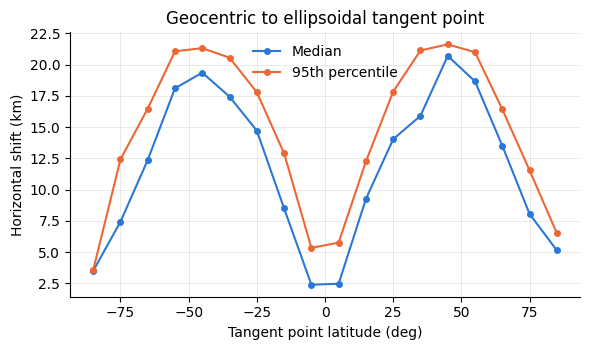

In [4]:
import matplotlib.pyplot as plt

BLUE, ORANGE, AQUA, GRAY, INK = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984", "#0b0b0b"
plt.rcParams.update(
    {"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6}
)

edges = np.arange(-90, 91, 10)
centers = (edges[1:] + edges[:-1]) / 2
binned = points.groupby(pd.cut(points.latitude, edges), observed=False).shift_km
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(centers, binned.median(), color=BLUE, marker="o", ms=4, label="Median")
ax.plot(centers, binned.quantile(0.95), color=ORANGE, marker="o", ms=4, label="95th percentile")
ax.set(xlabel="Tangent point latitude (deg)", ylabel="Horizontal shift (km)", title="Geocentric to ellipsoidal tangent point")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## Test 2: Operational Convention

UCAR reports a tangent point latitude and longitude at every altitude level of each retrieved profile. Above 50 km, ray bending is small (well below 0.1 mrad), so the bent ray and the straight line nearly coincide and each retrieved tangent point can be compared directly with the straight-line tangent point *at the same geodetic height*: for each definition, the point on its tangent point track where the height equals the level's altitude. No timing information is needed.

In [5]:
rows = []
for occ in occs:
    lev = occ["levels"]
    lev = lev[(lev.altitude > 50e3) & (lev.altitude < 80e3) & (lev.latitude.abs() <= 90)].iloc[::10]
    for k in DEFINITIONS:
        t = np.array([crossing(occ["t"], occ["lla"][k][2], a) for a in lev.altitude])
        ok = np.isfinite(t)
        lon, lat, _ = to_lla(interpolate(occ["t"], occ["points"][k], t[ok]))
        rows.append(
            pd.DataFrame(
                {
                    "occid": occ["occid"],
                    "definition": k,
                    "latitude": lev.latitude[ok],
                    "distance_km": GEOD.inv(lev.longitude[ok], lev.latitude[ok], lon, lat)[2] / 1e3,
                }
            )
        )
matched = pd.concat(rows, ignore_index=True)
matched.groupby("definition").distance_km.describe(percentiles=[0.5, 0.95]).loc[DEFINITIONS].round(3)

,count,mean,std,min,50%,95%,max
definition,,,,,,,
geocentric,30005.0,12.209,6.184,0.305,13.280,20.409,21.126
ellipsoidal,30005.0,0.270,0.484,0.002,0.104,1.205,4.234
curvature,30005.0,6.355,6.273,0.003,4.085,18.507,25.328


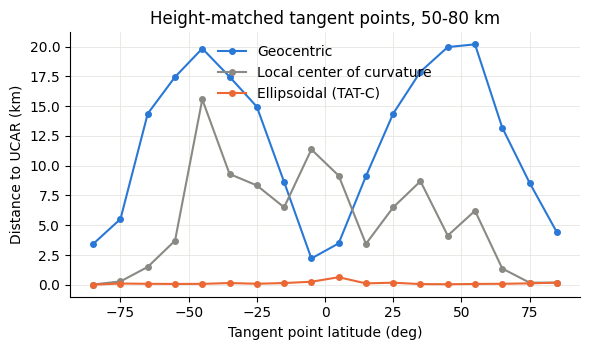

In [6]:
fig, ax = plt.subplots(figsize=(6, 3.6))
for k, color, label in [
    ("geocentric", BLUE, "Geocentric"),
    ("curvature", GRAY, "Local center of curvature"),
    ("ellipsoidal", ORANGE, "Ellipsoidal (TAT-C)"),
]:
    m = matched[matched.definition == k]
    ax.plot(centers, m.groupby(pd.cut(m.latitude, edges), observed=False).distance_km.median(), color=color, marker="o", ms=4, label=label)
ax.set(xlabel="Tangent point latitude (deg)", ylabel="Distance to UCAR (km)", title="Height-matched tangent points, 50-80 km")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

UCAR's tangent points coincide with the ellipsoidal definition at every latitude, including the polar regions (0.10 km median, 1.2 km at the 95th percentile), while the geocentric definition departs by up to about 20 km (median) near ±50 deg and by 2 to 4 km even near the equator and the poles. The local center of curvature, which UCAR uses for the retrieval itself, agrees near the poles but departs by up to about 15 km (median) at middle and low latitudes, so it is not the convention used for geolocation.

## Test 3: Practical Significance

TAT-C reports each occultation at the straight-line tangent point where the height crosses `sample_elevation` (-80 km by default), a stand-in for the bent ray's tangent point in the lowest troposphere. UCAR's reference location for each occultation (also the location in the AWS database) is instead the retrieved tangent point at about 12.5 km altitude, as for COSMIC-2. (UCAR's reference time, `refTime`, is simply the start of the Level 1A record.)

Because the tangent point drifts horizontally as the ray descends, TAT-C's default point naturally lies far from that reference location. For a like-for-like comparison, the straight-line height whose tangent point lies closest to each reference location is found first. TAT-C's representative point is then evaluated at the median of those heights under each definition.

In [7]:
best_height = []
for occ in occs:
    lon_e, lat_e, h_e = occ["lla"]["ellipsoidal"]
    d = GEOD.inv(np.full(lon_e.size, occ["ref_lon"]), np.full(lon_e.size, occ["ref_lat"]), lon_e, lat_e)[2]
    best_height.append(h_e[np.argmin(d)])
reference_height = np.median(best_height)

ref_rows = []
for occ in occs:
    row = {}
    for k in ["geocentric", "ellipsoidal"]:
        for name, height in [("-80 km", -80e3), ("matched", reference_height)]:
            tc = crossing(occ["t"], occ["lla"][k][2], height)
            lon, lat, _ = to_lla(interpolate(occ["t"], occ["points"][k], [tc]))
            row[f"{k}, {name}"] = GEOD.inv(lon[0], lat[0], occ["ref_lon"], occ["ref_lat"])[2] / 1e3 if np.isfinite(tc) else np.nan
    ref_rows.append(row)
reference = pd.DataFrame(ref_rows)
reference["geocentric minus ellipsoidal, matched"] = reference["geocentric, matched"] - reference["ellipsoidal, matched"]
print(f"straight-line height best matching UCAR's reference location: median {reference_height / 1e3:.1f} km "
      f"(5th-95th percentile {np.percentile(best_height, 5) / 1e3:.1f} to {np.percentile(best_height, 95) / 1e3:.1f} km)")
reference.describe(percentiles=[0.05, 0.5, 0.95]).T.round(2).rename_axis("distance to UCAR reference location (km)")

straight-line height best matching UCAR's reference location: median -0.5 km (5th-95th percentile -23.0 to 0.4 km)


,count,mean,std,min,5%,50%,95%,max
distance to UCAR reference location (km),,,,,,,,
"geocentric, -80 km",200.0,145.51,128.09,6.17,20.30,96.67,420.23,606.62
"geocentric, matched",200.0,13.48,10.75,0.21,1.75,8.63,33.09,34.31
"ellipsoidal, -80 km",200.0,143.77,129.19,4.95,13.72,94.42,418.90,606.70
"ellipsoidal, matched",200.0,13.19,0.23,12.53,12.76,13.20,13.53,13.74
"geocentric minus ellipsoidal, matched",200.0,0.29,10.73,-13.11,-11.42,-4.23,19.86,20.96


## Part 2: End-to-End Comparison

The remaining tests run `collect_ro_observations` for the whole day and compare its predictions with every GPS occultation PlanetiQ recorded. This needs orbits for the same day: two-line element sets (TLEs) for the GPS satellites, shared with the COSMIC-2 notebook as `gps_2026-05-14.3le` (see that notebook for its query), and for the GNOMES satellites, included with this notebook as `planetiq_2026-05-14.3le`. The GNOMES element sets were obtained from [Space-Track](https://www.space-track.org) (free account required) with the `gp_history` query

```
https://www.space-track.org/basicspacedata/query/class/gp_history/NORAD_CAT_ID/46266,52158,58462,60574/EPOCH/2026-05-13--2026-05-16/orderby/NORAD_CAT_ID%20asc,EPOCH%20asc/format/3le
```

which includes GNOMES-1 and GNOMES-3 as additional candidates for the identification below.

## Test 4: Orbits

GPS satellites are identified in RO data by their PRN code, which TLEs do not carry, and individual element sets can be poor (for example, around a maneuver). Each receiver and PRN is therefore matched to the satellite whose element sets best reproduce the positions recorded in the sampled Level 1A files (at the start, middle, and end of each occultation). Every element set of the matched satellite is then checked against those positions, and any set more than 20 km away is excluded.

In [8]:
import collections
from datetime import datetime, timedelta, timezone

from skyfield.api import Distance, wgs84
from skyfield.framelib import itrs
from skyfield.positionlib import Geocentric

from tatc.constants import timescale
from tatc.schemas import GeneralPerturbationsOrbit, Satellite

DAY0 = datetime(2026, 5, 14, tzinfo=timezone.utc)
GPS_EPOCH = datetime(1980, 1, 6, tzinfo=timezone.utc)
GPS_UTC_OFFSET = 18  # s, GPS time minus UTC in 2026

# element sets per NORAD catalog number, keyed by epoch (later duplicates win)
tle_lines = [
    line.rstrip()
    for path in ["gps_2026-05-14.3le", "planetiq_2026-05-14.3le"]
    for line in open(path)
    if line.strip()
]
element_sets, names = collections.defaultdict(dict), {}
for i in range(0, len(tle_lines), 3):
    line1, line2 = tle_lines[i + 1], tle_lines[i + 2]
    names[line1[2:7]] = tle_lines[i][2:].strip()
    element_sets[line1[2:7]][float(line1[18:32])] = [line1, line2]


def to_orbit(sets):
    return GeneralPerturbationsOrbit.from_tle(sum((sets[e] for e in sorted(sets)), []))


def ecf(orbit, times):
    """Earth-fixed positions (m) of an orbit at datetimes."""
    ts = timescale.from_datetimes(times)
    p = np.array(orbit.get_orbit_track_at_time(ts).position.m)
    return np.einsum("ij...,j...->i...", itrs.rotation_at(ts), p)


# recorded positions of each receiver and transmitter
recorded = collections.defaultdict(list)
for record in sample._data:
    l1 = nc.Dataset(os.path.join(DATA_DIR, os.path.basename(record["ucar_calibratedPhase"])))
    l1.set_auto_mask(False)
    for k in [0, l1["time"].size // 2, l1["time"].size - 1]:
        t = GPS_EPOCH + timedelta(seconds=float(l1["startTime"][...]) - GPS_UTC_OFFSET + float(l1["time"][k]))
        recorded[record["transmitter"]].append((t, l1["positionGNSS"][k].astype(float)))
        recorded[record["receiver"]].append((t, l1["positionLEO"][k].astype(float)))


def position_errors(orbit, key):
    times = [t for t, _ in recorded[key]]
    return np.linalg.norm(ecf(orbit, times) - np.array([p for _, p in recorded[key]]).T, axis=0) / 1e3


rows, satellites = [], {}
for key in sorted(recorded):
    best_single = {
        norad: min(np.median(position_errors(to_orbit({e: s}), key)) for e, s in sets.items())
        for norad, sets in element_sets.items()
    }
    norad = min(best_single, key=best_single.get)
    sets = element_sets[norad]
    excluded = [e for e, s in sets.items() if position_errors(to_orbit({e: s}), key).max() > 20]
    kept = {e: s for e, s in sets.items() if e not in excluded}
    satellites[key] = Satellite(name=key, orbit=to_orbit(kept))
    errors = position_errors(satellites[key].orbit, key)
    rows.append(
        {
            "key": key,
            "NORAD": norad,
            "name": names[norad],
            "element sets": len(kept),
            "excluded sets": len(excluded),
            "median error (km)": np.median(errors),
            "max error (km)": errors.max(),
            "next-best satellite (km)": sorted(best_single.values())[1],
        }
    )
orbit_check = pd.DataFrame(rows).set_index("key")
receivers = [satellites[k] for k in sorted(satellites) if k.startswith("planetiq")]
transmitters = [satellites[k] for k in sorted(satellites) if k.startswith("G")]
orbit_check.round(2)

,NORAD,name,element sets,excluded sets,median error (km),max error (km),next-best satellite (km)
key,,,,,,,
G01,62339,NAVSTAR 83 (USA 440),3,0,0.78,1.15,11746.78
G03,40294,NAVSTAR 72 (USA 258),4,0,0.64,0.72,20936.11
G04,43873,NAVSTAR 77 (USA 289),2,0,0.23,0.55,12989.18
G05,35752,NAVSTAR 64 (USA 206),4,0,3.96,4.24,11192.71
G06,39741,NAVSTAR 70 (USA 251),4,0,4.52,4.68,15271.13
G07,32711,NAVSTAR 62 (USA 201),3,0,0.68,0.76,10915.98
G08,40730,NAVSTAR 74 (USA 262),3,0,3.11,3.77,13038.09
G09,40105,NAVSTAR 71 (USA 256),3,0,1.38,1.51,13079.59
G10,41019,NAVSTAR 75 (USA 265),5,0,1.86,2.18,14419.47


Every receiver and PRN is identified unambiguously (the next-best satellite is at least 1,800 km away): receiver planetiqGN04 is GNOMES-4 and planetiqGN05 is GNOMES-5. Using the element set nearest in time, as TAT-C does, all orbits stay within about 5 km of the recorded positions, with no element sets excluded. PlanetiQ recorded no GPS occultations on this day from six PRNs (G02, G13, G16, G19, G22, and G27), so these do not appear in the sample, and the remaining tests use the 26 GPS satellites PlanetiQ tracked.

## Observed Occultations

The AWS database lists every GPS occultation PlanetiQ recorded on 14 May, with its receiver, transmitter, rising or setting flag, and UCAR's reference location. As for COSMIC-2, its time stamp (the minute in the `occid`) marks the start of the record for setting occultations and the end for rising ones, roughly when the straight line passes 110 to 140 km. To compare like with like, each observed occultation's time at TAT-C's default `sample_elevation` (-80 km), and the transmitter's yaw angle in TAT-C's receiver frame at that time, are computed from the same orbits. A few PlanetiQ occultations descend slowly, so the search extends 10 minutes either side of the time stamp.

In [9]:
from tatc.analysis.ro_coverage import _receiver_frame_vectors, _tangent_point_geometry

observed = pd.DataFrame(
    [
        {
            "occid": r["occid"],
            "receiver": r["receiver"],
            "transmitter": r["transmitter"],
            "stamp": datetime.fromisoformat(r["time"]).replace(tzinfo=timezone.utc),
            "setting": bool(r["setting"]),
            "ref_lat": r["latitude"],
            "ref_lon": r["longitude"],
        }
        for r in occultations._data
        if r["transmitter"].startswith("G")
    ]
)
offsets = np.arange(-600.0, 600.0, 1.0)
t80, yaw80 = [], []
for o in observed.itertuples():
    ts = timescale.from_datetimes([o.stamp + timedelta(seconds=s) for s in offsets])
    rx_pv = satellites[o.receiver].orbit.to_gp_orbit().get_orbit_track_at_time(ts)
    tx_pv = satellites[o.transmitter].orbit.to_gp_orbit().get_orbit_track_at_time(ts)
    tp, tp_sign, _, yaw = _tangent_point_geometry(tx_pv, rx_pv, *_receiver_frame_vectors(rx_pv))
    height = wgs84.geographic_position_of(Geocentric(Distance(m=tp).au, None, ts)).elevation.m
    height[tp_sign > 0] = np.nan  # tangent point not between receiver and transmitter
    s = np.sign(height + 80e3)
    crossings = np.nonzero(s[:-1] * s[1:] < 0)[0]
    if len(crossings) == 0:  # does not reach -80 km within the search window
        t80.append(pd.NaT)
        yaw80.append(np.nan)
        continue
    j = crossings[0]
    w = (height[j] + 80e3) / (height[j] - height[j + 1])
    t80.append(o.stamp + timedelta(seconds=offsets[j] + w))
    yaw80.append(yaw[j] + w * (((yaw[j + 1] - yaw[j] + 180) % 360) - 180))
observed["t80"] = pd.to_datetime(t80)
observed["yaw80"] = yaw80
unresolved = int(observed.t80.isna().sum())
observed = observed[(observed.t80 >= DAY0) & (observed.t80 < DAY0 + timedelta(days=1))].reset_index(drop=True)


def folded(yaw):
    """Yaw angle from the nearer of the forward and rearward directions (deg)."""
    yaw = np.abs(np.asarray(yaw, dtype=float))
    return np.minimum(yaw, 180 - yaw)


print(f"{len(observed)} observed GPS occultations reach -80 km on 14 May ({unresolved} not resolved within the search window)")
pd.Series(
    np.percentile(folded(observed.yaw80), [50, 90, 95, 99, 100]), index=["50%", "90%", "95%", "99%", "max"]
).to_frame("observed yaw from fore/aft (deg)").T.round(1)

1382 observed GPS occultations reach -80 km on 14 May (0 not resolved within the search window)


,50%,90%,95%,99%,max
observed yaw from fore/aft (deg),28.6,59.7,64.7,77.5,84.3


PlanetiQ observes occultations up to 84 deg from its forward or rearward direction. Most lie within TAT-C's default `max_yaw` of 65 deg (95%), but PlanetiQ's coverage extends further than COSMIC-2's, which ended at about 64 deg.

## Test 5: Predicted and Observed Occultations

`collect_ro_observations` is run for each receiver against the 26 GPS satellites PlanetiQ tracked over the day, with a 1 s `time_step` and otherwise default settings (including the default `max_yaw` of 65 deg). The run takes about a minute, and its results are cached in `data/ro`. Predictions and observations are paired one to one by receiver, transmitter, and time at -80 km, within 60 s.

In [10]:
from tatc.analysis import collect_ro_observations

cache = os.path.join(DATA_DIR, "predicted_planetiq.pkl")
if not os.path.exists(cache):
    pd.concat(
        [
            collect_ro_observations(receiver, transmitters, DAY0, DAY0 + timedelta(days=1), time_step=timedelta(seconds=1))
            for receiver in receivers
        ],
        ignore_index=True,
    ).to_pickle(cache)
predicted = pd.read_pickle(cache)


def pair(pred, obs, tolerance=60):
    """One-to-one (predicted index, observed index) pairs by receiver, transmitter, and time."""
    candidates = []
    for (rx, tx), p in pred.groupby(["receiver", "transmitter"]):
        o = obs[(obs.receiver == rx) & (obs.transmitter == tx)]
        dt = np.abs((p.time.values[:, None] - o.t80.values[None, :]) / np.timedelta64(1, "s"))
        candidates += [(dt[i, j], p.index[i], o.index[j]) for i, j in zip(*np.nonzero(dt < tolerance))]
    used_p, used_o, pairs = set(), set(), []
    for _, i, j in sorted(candidates):
        if i not in used_p and j not in used_o:
            used_p.add(i)
            used_o.add(j)
            pairs.append((i, j))
    return pd.DataFrame(pairs, columns=["pred", "obs"])


pairs = pair(predicted, observed)
pd.DataFrame(
    {
        "predicted": len(predicted),
        "observed": len(observed),
        "matched": len(pairs),
        "share of observed that were predicted": len(pairs) / len(observed),
        "share of predicted that were observed": len(pairs) / len(predicted),
        "rising/setting agreement (matched)": np.mean(
            predicted.loc[pairs.pred, "is_rising"].values == ~observed.loc[pairs.obs, "setting"].values
        ),
    },
    index=pd.Index([65], name="max_yaw (deg)"),
).round(3)

,predicted,observed,matched,share of observed that were predicted,share of predicted that were observed,rising/setting agreement (matched)
max_yaw (deg),,,,,,
65,1479,1382,1317,0.953,0.89,1.0


With the default `max_yaw` of 65 deg, TAT-C predicts 1,317 of the 1,382 observed occultations (95%) and labels each correctly as rising or setting. Every one of the 65 it misses was observed at a yaw angle beyond 65 deg (66 to 84 deg), outside the default limit. TAT-C predicts 1,479 occultations, of which 89% were recorded, a much higher share than for COSMIC-2 (69%); Test 6 examines the rest.

## Test 6: Which Predicted Occultations Are Observed?

At the default `max_yaw`, the share of predicted occultations that PlanetiQ actually recorded is broken down by receiver and transmitter, by hour, by yaw angle, by direction, and by the number of other occultations the same receiver could track in the same direction at the same time.

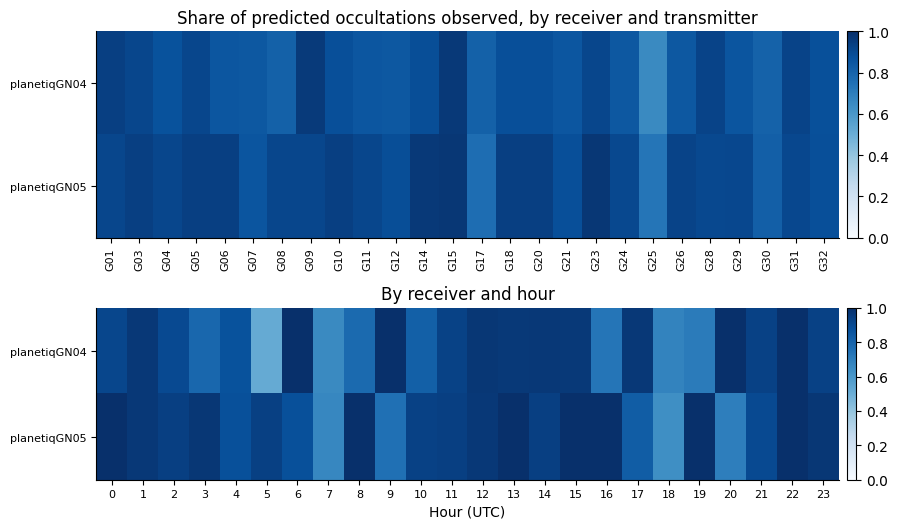

In [11]:
pred = predicted.copy()
pred["seen"] = False
pred.loc[pairs.pred, "seen"] = True
pred["yaw"] = folded(pred.rx_tx_yaw)
pred["hour"] = pred.time.dt.hour
pred["concurrent"] = [
    int(((pred.receiver == r.receiver) & (pred.is_rising == r.is_rising) & (pred.start < r.end) & (pred.end > r.start)).sum() - 1)
    for r in pred.itertuples()
]
by_pair = pred.pivot_table(index="receiver", columns="transmitter", values="seen", aggfunc="mean")
hourly = pred.groupby(["hour", "receiver"])["seen"].mean().unstack()  # hours x receivers

fig, axes = plt.subplots(2, 1, figsize=(10, 5.4), gridspec_kw={"height_ratios": [1.2, 1]})
im = axes[0].imshow(by_pair.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
axes[0].set_xticks(range(by_pair.shape[1]), by_pair.columns, rotation=90, fontsize=8)
axes[0].set_yticks(range(by_pair.shape[0]), by_pair.index, fontsize=8)
axes[0].grid(False)
axes[0].set_title("Share of predicted occultations observed, by receiver and transmitter")
fig.colorbar(im, ax=axes[0], pad=0.01)
im = axes[1].imshow(hourly.T.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
axes[1].set_xticks(range(hourly.shape[0]), hourly.index, fontsize=8)
axes[1].set_yticks(range(hourly.shape[1]), hourly.columns, fontsize=8)
axes[1].grid(False)
axes[1].set(xlabel="Hour (UTC)", title="By receiver and hour")
fig.colorbar(im, ax=axes[1], pad=0.01)
fig.tight_layout()
plt.show()

Every receiver-transmitter combination was recorded regularly (none below the 10% threshold used to exclude untracked combinations for COSMIC-2), so all predictions enter the breakdown by geometry and tracking load:

In [12]:
seen_rate = pred.groupby(["receiver", "transmitter"])["seen"].transform("mean")
tracked = pred[seen_rate > 0.1]
groups = {
    # arcs cut off by the yaw limit report a yaw of exactly max_yaw (up to round-off)
    "yaw from fore/aft (deg)": pd.cut(tracked.yaw.clip(upper=65), [0, 15, 30, 45, 55, 60, 65]).astype(str),
    "direction": tracked.is_rising.map({True: "rising", False: "setting"}),
    "other same-direction occultations at the same time": tracked.concurrent.clip(upper=3).astype(str).replace("3", "3 or more"),
}
pd.concat(
    {name: tracked.groupby(key)["seen"].agg(["mean", "size"]) for name, key in groups.items()}
).rename(columns={"mean": "share observed", "size": "predicted"}).round(2)

share observed  \
yaw from fore/aft (deg)                            (0, 15]              0.89   
                                                   (15, 30]             0.90   
                                                   (30, 45]             0.88   
                                                   (45, 55]             0.90   
                                                   (55, 60]             0.91   
                                                   (60, 65]             0.83   
direction                                          rising               0.86   
                                                   setting              0.92   
other same-direction occultations at the same time 0                    0.91   
                                                   1                    0.87   
                                                   2                    0.86   
                                                   3 or more            1.00   

                                                              predicted  
yaw from fore/aft (deg)                            (0, 15]          365  
                                                   (15, 30]         442  
                                                   (30, 45]         337  
                                                   (45, 55]         175  
                                                   (55, 60]          79  
                                                   (60, 65]          81  
direction                                          rising           739  
                                                   setting          740  
other same-direction occultations at the same time 0                730  
                                                   1                602  
                                                   2                133  
                                                   3 or more         14

Unlike COSMIC-2, PlanetiQ shows no untracked receiver-transmitter combinations and no extended data gaps: both receivers recorded at least half of the predicted occultations in every hour, and at least 69% for every transmitter (lowest for G25 and G17). The recorded share is nearly independent of yaw angle up to 60 deg (88 to 91%) and falls only to 83% between 60 and 65 deg, consistent with antenna coverage that extends beyond 65 deg. As for COSMIC-2, setting occultations were recorded more often than rising ones (92% vs 86%), and the share decreases slightly when several occultations compete for the same receiver. Counting the recordings beyond 65 deg as well, PlanetiQ recorded 93% as many GPS occultations as TAT-C predicts with the default settings.

## Test 7: Timing and Location of Matched Occultations

For matched occultations, TAT-C's `time` and `position` (at -80 km) are compared with the true straight-line tangent point from the recorded positions (for the sampled occultations), alongside the geocentric definition evaluated with the same orbits. Separately, every matched occultation's tangent point at the straight-line height found in Test 3 to best match UCAR's reference location (-0.5 km) is compared with that location under both definitions.

In [13]:
sampled = {o["occid"]: o for o in occs}
LABELS = {"ellipsoidal": "TAT-C (ellipsoidal)", "geocentric": "geocentric"}
seconds = np.arange(-240.0, 240.0, 1.0)
rows = []
for i, j in zip(pairs.pred, pairs.obs):
    p, o = pred.loc[i], observed.loc[j]
    times = [p.time.to_pydatetime() + timedelta(seconds=s) for s in seconds]
    tle_points = tangent_points(
        ecf(satellites[p.receiver].orbit.to_gp_orbit(), times),
        ecf(satellites[p.transmitter].orbit.to_gp_orbit(), times),
        timescale.from_datetimes(times),
    )
    row = {}
    for k in ["geocentric", "ellipsoidal"]:
        tc = crossing(seconds, _geodetic_altitude(tle_points[k]), reference_height)
        if np.isfinite(tc):
            lon, lat, _ = to_lla(interpolate(seconds, tle_points[k], [tc]))
            row[f"{LABELS[k]}: reference-height point to UCAR reference location (km)"] = GEOD.inv(lon[0], lat[0], o.ref_lon, o.ref_lat)[2] / 1e3
    if o.occid in sampled:
        occ = sampled[o.occid]
        true_t80 = crossing(occ["t"], occ["lla"]["ellipsoidal"][2], -80e3)
        start = GPS_EPOCH + timedelta(seconds=occ["start"] - GPS_UTC_OFFSET)
        lon, lat, _ = to_lla(interpolate(occ["t"], occ["points"]["ellipsoidal"], [true_t80]))
        row["TAT-C time minus true time at -80 km (s)"] = (p.time.to_pydatetime() - start).total_seconds() - true_t80
        row["TAT-C position: -80 km point to truth (km)"] = GEOD.inv(p.position.x, p.position.y, lon[0], lat[0])[2] / 1e3
        tc = crossing(seconds, _geodetic_altitude(tle_points["geocentric"]), -80e3)
        lon_g, lat_g, _ = to_lla(interpolate(seconds, tle_points["geocentric"], [tc]))
        row["geocentric: -80 km point to truth (km)"] = GEOD.inv(lon_g[0], lat_g[0], lon[0], lat[0])[2] / 1e3
    rows.append(row)
accuracy = pd.DataFrame(rows)
accuracy.describe(percentiles=[0.5, 0.95]).T.round(3)

,count,mean,std,min,50%,95%,max
geocentric: reference-height point to UCAR reference location (km),1273.0,13.928,10.676,0.109,10.291,32.735,34.459
TAT-C (ellipsoidal): reference-height point to UCAR reference location (km),1273.0,13.184,0.391,11.907,13.202,13.806,14.536
TAT-C time minus true time at -80 km (s),195.0,0.018,0.127,-0.371,0.004,0.216,0.366
TAT-C position: -80 km point to truth (km),195.0,0.443,0.355,0.012,0.330,1.120,1.854
geocentric: -80 km point to truth (km),195.0,12.611,6.321,0.395,13.795,20.865,21.859


TAT-C's `time` agrees with the true time at which the straight line reaches -80 km to within 0.22 s (95th percentile), and its `position` with the true straight-line tangent point to 0.33 km (median) and 1.1 km (95th percentile), both limited only by orbit accuracy. The geocentric definition places the same points 13.8 km (median) and 21 km (95th percentile) away, more than for COSMIC-2 because PlanetiQ samples more middle and high latitudes.

Against UCAR's reference location, across all 1,273 matched occultations with a retrieval, the ellipsoidal definition gives a nearly constant 13.2 km (median; 11.9 to 14.5 km), while the geocentric definition scatters from 0.1 to 34 km (10.3 km median, 33 km at the 95th percentile), consistent with Test 3. The geocentric median is smaller only because its shift along the ray (up to 21 km) sometimes offsets, and sometimes adds to, the nearly constant offset caused by ray bending.

## Summary

| Test | Result |
| --- | --- |
| 1. Size of the difference | Horizontal shift of 12.5 km (median), 21 km (95th percentile), 22 km (maximum), largest near ±45 to 55 deg and decreasing to 3.5 to 5 km near the poles; height difference under 37 m; time difference under 0.03 s |
| 2. Operational convention (50-80 km) | Distance to UCAR's tangent points: ellipsoidal 0.10 km (median) at all latitudes, geocentric 13.3 km, local center of curvature 4.1 km |
| 3. At the height matching UCAR's reference location (-0.5 km) | Distance to the reference location: ellipsoidal 13.2 km (median) and 13.5 km (95th percentile); geocentric 8.6 km and 33 km |
| 3. At the default `sample_elevation` (-80 km) | About 95 km from the reference location under either definition |
| 4. Orbits (TLEs vs. recorded positions) | Within about 5 km for all 26 tracked GPS satellites and both receivers, with no element sets excluded |
| 5. Predicted vs. observed (default `max_yaw` = 65 deg) | 95% of the 1,382 observed occultations predicted, with correct rising/setting; all 65 missed ones observed beyond 65 deg yaw; 89% of the 1,479 predicted occultations recorded |
| 6. Detection | No untracked combinations or data gaps; recorded share nearly independent of yaw angle (83% at 60-65 deg); setting recorded more often than rising |
| 7. Timing and location | `time` within 0.22 s (95th percentile); `position` 0.33 km (median) and 1.1 km (95th percentile) from the true tangent point, versus 13.8 km and 21 km with the geocentric definition |

**TAT-C's RO geometry is validated for a polar orbit.** With published orbits, `collect_ro_observations` predicts 95% of the GPS occultations PlanetiQ recorded on this day, labels each correctly as rising or setting, and reports its time to a fraction of a second and its position to a third of a kilometer (median). PlanetiQ recorded 89% of TAT-C's predictions, with no untracked transmitters or data gaps, so predicted counts are close to recorded counts.

**The ellipsoidal tangent point matches operational geolocation at all latitudes.** UCAR's PlanetiQ tangent points agree with TAT-C's ellipsoidal definition to 0.10 km (median) from pole to pole. Because PlanetiQ samples middle latitudes, where the geocentric definition departs most, the geocentric definition would have placed occultations 13.8 km away (median), compared with 2.9 km for COSMIC-2. Heights and times differ negligibly between the definitions, so counts, timing, and the start and end of each occultation do not depend on the choice.

**PlanetiQ's coverage extends beyond the default `max_yaw`.** The 65 deg default, which matches COSMIC-2's coverage, excludes 5% of PlanetiQ's recorded occultations (up to 84 deg, 99th percentile 78 deg); a larger `max_yaw` would be needed to represent PlanetiQ's full coverage.

**Ray bending, not the definition, limits the representative point.** As for COSMIC-2, a straight-line model places the occultation a nearly constant 13 km from UCAR's reference location. The straight-line height that best reproduces the reference location is -0.5 km (median), compared with -3 km for COSMIC-2, likely because the drier atmosphere at high latitudes bends rays less; the default `sample_elevation` of -80 km lies about 95 km from the reference location along the profile.

**Next steps:**

1. *Other constellations.* PlanetiQ also tracks GLONASS, Galileo, and BeiDou; extending the comparison to those transmitters would test TAT-C with other orbit geometries.
2. *More receivers.* Repeat for Spire's receivers, which fly in polar orbits at altitudes from about 410 to 575 km.
3. *More days.* Repeat on additional days to confirm that the detection share and the observed yaw coverage are stable.

**Limitations.** This study covers one day, UCAR processing only, and GPS transmitters only; Part 1 and the timing and truth comparisons of Test 7 use a random sample of 200 occultations.